# Focused EDA for Severity Insight

Objective:
- Identify factors associated with accident severity
- Focus only on features used in the final severity prediction model
- Avoid data leakage by excluding post-incident variables

This notebook performs:
- Feature × Target (Severity) analysis
- Comparative and aggregated analysis
- Insight extraction for interpretation and policy discussion


Cell 1: Setup & Load Data
เราจะโหลดไฟล์ accidents_clean.parquet (ที่มีชื่อรัฐ/เมือง) และสร้างฟีเจอร์สำคัญกลับขึ้นมาใหม่เพื่อใช้ในการพลอตกราฟครับ

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ตั้งค่ากราฟให้สวยงาม
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. โหลดข้อมูลที่คลีนแล้ว (ที่มีชื่อ State และ City)
print("Loading data...")
df = pd.read_parquet("../data/processed/accidents_clean.parquet")

# 2. สร้างฟีเจอร์สำคัญ (เหมือนไฟล์ 03) เพื่อใช้พลอตกราฟคู่กับชื่อรัฐ
# (เราทำตรงนี้อีกรอบเพราะไฟล์ clean ยังไม่มีฟีเจอร์พวกนี้)
print("Re-creating analysis features...")

# 2.1 Critical Keywords
critical_keywords = ['fatal', 'closed', 'blocked', 'multi-vehicle', 'severe']
pattern = '|'.join(critical_keywords)
df['Is_Critical_Description'] = df['Description'].str.contains(pattern, case=False, na=False).astype(int)

# 2.2 Area Density (ความหนาแน่นพื้นที่)
df['Lat_bin'] = df['Start_Lat'].round(1)
df['Lng_bin'] = df['Start_Lng'].round(1)
density = df.groupby(['Lat_bin', 'Lng_bin']).size().rename('Count')
df = df.merge(density, on=['Lat_bin', 'Lng_bin'], how='left')
df['Area_Density_Level'] = pd.qcut(df['Count'], q=3, labels=['Low', 'Medium', 'High'])

print(f"Data Loaded: {len(df):,} rows")
display(df.head(3))

Loading data...
Re-creating analysis features...
Data Loaded: 6,985,228 rows


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,End_Hour,End_Weekday,Is_Weekend,Accident_Duration_Min,Has_Precipitation,Is_Critical_Description,Lat_bin,Lng_bin,Count,Area_Density_Level
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,11.0,0.0,0,314.0,1,1,39.9,-84.1,161,Low
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,6.0,0.0,0,30.0,1,0,39.9,-82.8,1038,Low
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,7.0,0.0,0,30.0,0,0,39.1,-84.0,25,Low


Cell 2: Insight 1 - "Quantity vs Quality" (รัฐไหนอันตรายของจริง?)
กราฟนี้จะเปรียบเทียบ "จำนวนอุบัติเหตุ" vs "อัตราการเกิดเหตุรุนแรง (Severity 4)" เพื่อดูว่ารัฐที่อุบัติเหตุเยอะ อาจไม่ได้น่ากลัวที่สุดเสมอไป

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19640\1984824009.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_vol, x='State', y='Total_Accidents', palette='Blues_r', ax=axes[0])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19640\1984824009.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_risk, x='State', y='Sev4_Rate(%)', palette='Reds_r', ax=axes[1])


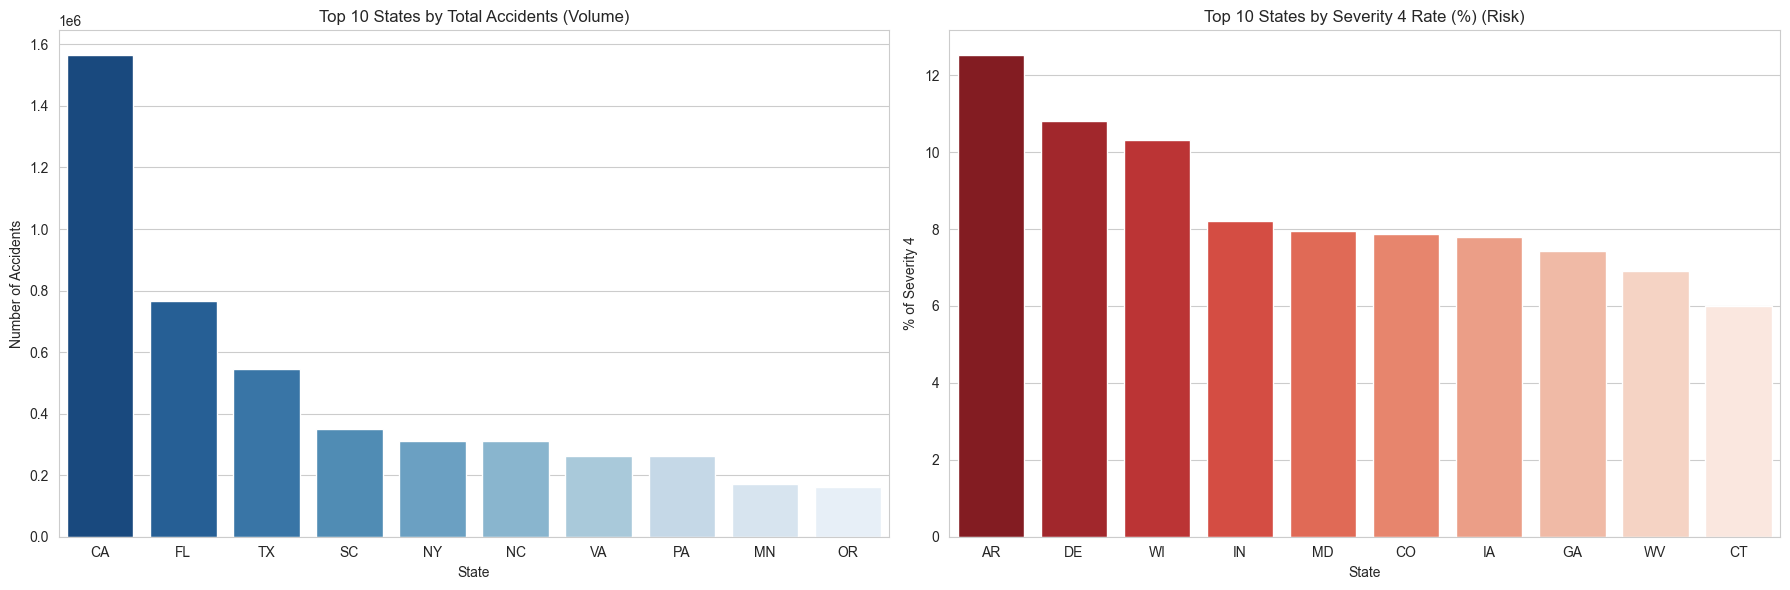

Insight: สังเกตว่ารัฐทางขวา (Risk) อาจไม่ใช่รัฐเดียวกับทางซ้าย (Volume) เสมอไป


In [2]:
# 1. คำนวณสถิติรายรัฐ
state_stats = df.groupby('State').agg(
    Total_Accidents=('Severity', 'count'),
    Sev4_Count=('Severity', lambda x: (x == 4).sum())
).reset_index()

# คำนวณ % Severity 4
state_stats['Sev4_Rate(%)'] = (state_stats['Sev4_Count'] / state_stats['Total_Accidents']) * 100

# 2. พลอตกราฟเปรียบเทียบ
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# กราฟซ้าย: รัฐที่มีอุบัติเหตุ "เยอะที่สุด" (Volume)
top_vol = state_stats.sort_values('Total_Accidents', ascending=False).head(10)
sns.barplot(data=top_vol, x='State', y='Total_Accidents', palette='Blues_r', ax=axes[0])
axes[0].set_title('Top 10 States by Total Accidents (Volume)')
axes[0].set_ylabel('Number of Accidents')

# กราฟขวา: รัฐที่มีอุบัติเหตุ "รุนแรงที่สุด" (Risk) - กรองเฉพาะรัฐที่มีอุบัติเหตุ > 5000 ครั้งเพื่อความแฟร์
top_risk = state_stats[state_stats['Total_Accidents'] > 5000].sort_values('Sev4_Rate(%)', ascending=False).head(10)
sns.barplot(data=top_risk, x='State', y='Sev4_Rate(%)', palette='Reds_r', ax=axes[1])
axes[1].set_title('Top 10 States by Severity 4 Rate (%) (Risk)')
axes[1].set_ylabel('% of Severity 4')

plt.tight_layout()
plt.show()

print("Insight: สังเกตว่ารัฐทางขวา (Risk) อาจไม่ใช่รัฐเดียวกับทางซ้าย (Volume) เสมอไป")

Cell 3: Insight 2 - Geospatial Risk Map (แผนที่จุดเสี่ยงตาย)
เราจะสุ่มข้อมูลมาพล็อตลงบนแผนที่ เพื่อดูการกระจายตัวว่า Severity 4 กระจุกตัวอยู่ที่ไหน (ในเมืองหรือชนบท?)

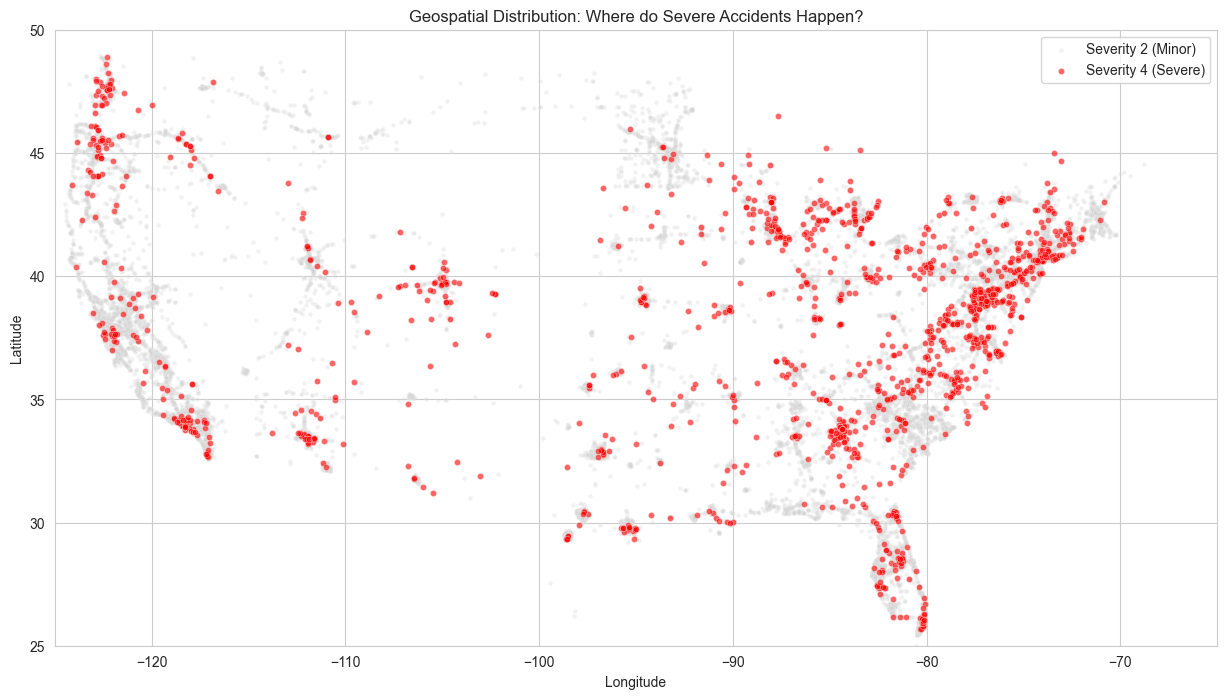

In [3]:
# สุ่มข้อมูลมา 50,000 จุด เพื่อไม่ให้กราฟหน่วงเกินไป
sample_df = df.sample(n=50000, random_state=42)

plt.figure(figsize=(15, 8))

# 1. พล็อตจุดปกติ (Severity 2) เป็นพื้นหลังสีจางๆ
sns.scatterplot(
    data=sample_df[sample_df['Severity'] == 2], 
    x='Start_Lng', y='Start_Lat', 
    color='lightgrey', alpha=0.3, s=10, label='Severity 2 (Minor)'
)

# 2. พล็อตจุดอันตราย (Severity 4) สีแดงเข้มทับลงไป
sns.scatterplot(
    data=sample_df[sample_df['Severity'] == 4], 
    x='Start_Lng', y='Start_Lat', 
    color='red', alpha=0.6, s=20, label='Severity 4 (Severe)'
)

plt.title('Geospatial Distribution: Where do Severe Accidents Happen?')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.xlim(-125, -65) # โฟกัสเฉพาะแผ่นดินใหญ่ USA
plt.ylim(25, 50)
plt.show()

Cell 4: Insight 3 - "The Kill Zone" (Heatmap ช่วงเวลาอันตราย)
ดูความสัมพันธ์ระหว่าง "วันในสัปดาห์" และ "ช่วงเวลา" ว่าตอนไหนเกิด Severity 4 บ่อยที่สุด

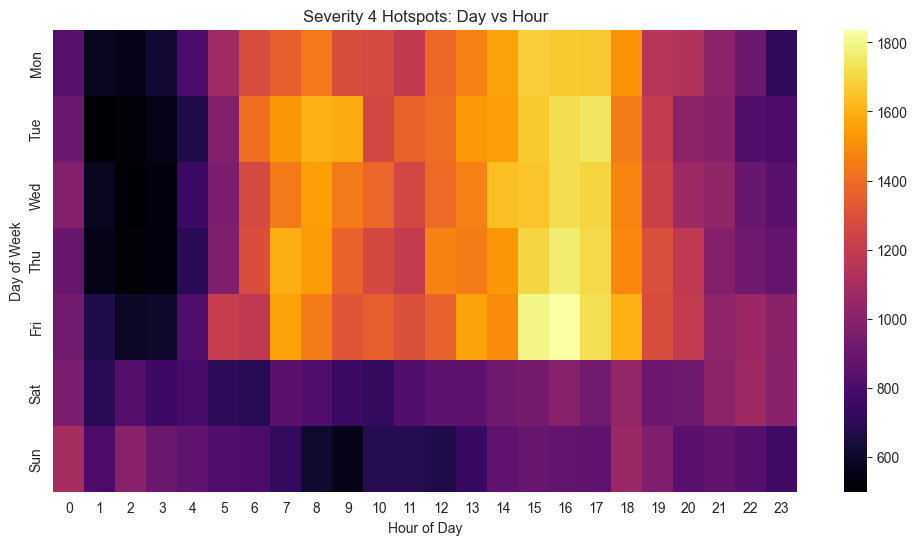

Insight: ลองดูช่วงเช้าวันทำงาน (Rush Hour) vs คืนวันศุกร์/เสาร์


In [4]:
# กรองเฉพาะ Severity 4
sev4_df = df[df['Severity'] == 4]

# สร้างตาราง Pivot: แกน X=ชั่วโมง, แกน Y=วันในสัปดาห์
heatmap_data = sev4_df.pivot_table(
    index='Start_Weekday', 
    columns='Start_Hour', 
    values='Severity', 
    aggfunc='count'
).fillna(0)

# เปลี่ยนเลขวันเป็นชื่อวัน
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
heatmap_data.index = days

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='inferno', annot=False, fmt='g')
plt.title('Severity 4 Hotspots: Day vs Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()

print("Insight: ลองดูช่วงเช้าวันทำงาน (Rush Hour) vs คืนวันศุกร์/เสาร์")

Cell 5: Insight 4 - Impact of Critical Factors (ปัจจัยชี้ขาด)
มายืนยันกันชัดๆ อีกครั้งว่า Keyword และ พื้นที่ ส่งผลต่อความรุนแรงจริงไหม

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19640\67047351.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Is_Critical_Description', y='Severity', estimator=np.mean, ax=axes[0], palette='viridis')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19640\67047351.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=density_risk, x='Area_Density_Level', y='Severity', order=['Low', 'Medium', 'High'], palette='magma', ax=axes[1])


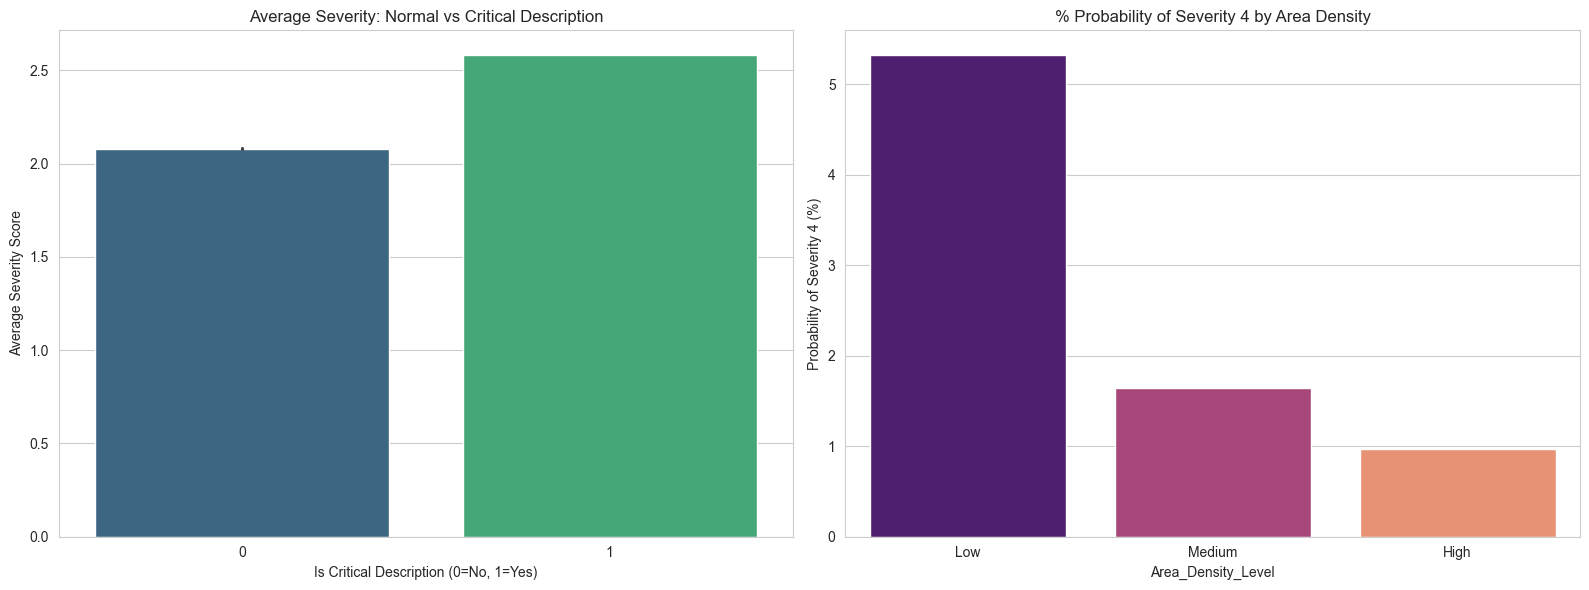

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. ผลกระทบของคำสำคัญ (Critical Description)
sns.barplot(data=df, x='Is_Critical_Description', y='Severity', estimator=np.mean, ax=axes[0], palette='viridis')
axes[0].set_title('Average Severity: Normal vs Critical Description')
axes[0].set_xlabel('Is Critical Description (0=No, 1=Yes)')
axes[0].set_ylabel('Average Severity Score')

# 2. ผลกระทบของความหนาแน่น (Area Density)
# พล็อตสัดส่วน Severity 4 ในแต่ละพื้นที่
density_risk = df.groupby('Area_Density_Level')['Severity'].apply(lambda x: (x==4).mean() * 100).reset_index()
sns.barplot(data=density_risk, x='Area_Density_Level', y='Severity', order=['Low', 'Medium', 'High'], palette='magma', ax=axes[1])
axes[1].set_title('% Probability of Severity 4 by Area Density')
axes[1].set_ylabel('Probability of Severity 4 (%)')

plt.tight_layout()
plt.show()